# Computational Social Science Project #3 

Ishika Sachdeva

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [1]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

# settings
%matplotlib inline
#sns.set_style("darkgrid")
# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
# this will be the test dataset 
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [12]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [13]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [3]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [4]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

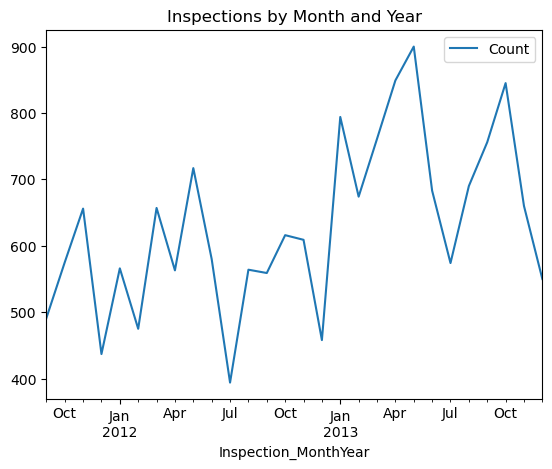

In [5]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 
plt.show()

Let's visualize what the distribution of results looks like.

The most inspections were done in April 2013.

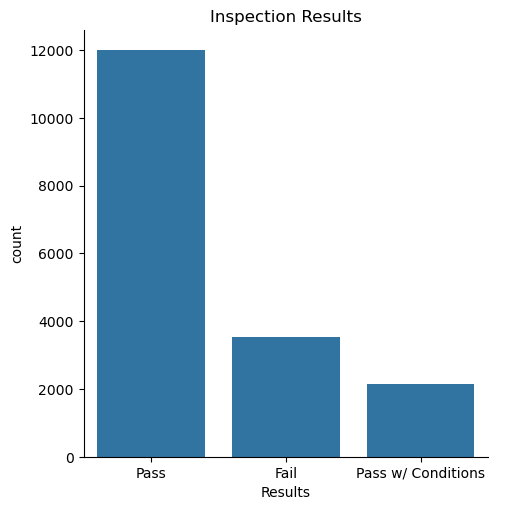

In [17]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

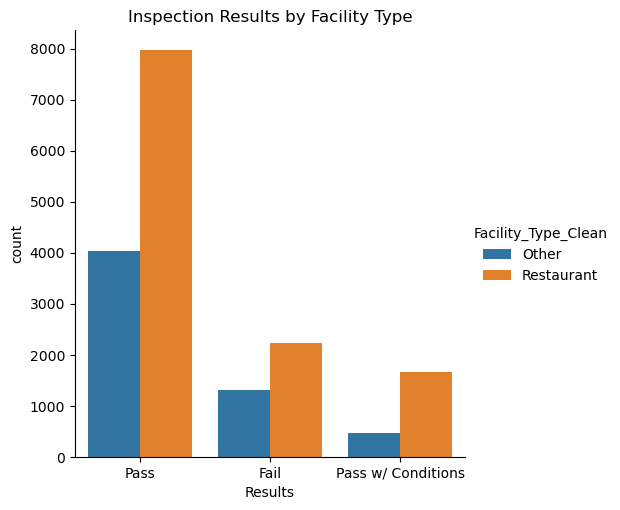

In [18]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

More restaurants pass than others, but more restaurants also fail than others. 

## 2. Data Preprocessing and Cleaning

In [6]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [8]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

# we dropped the columns in our feature dataset that we are interested in. 
# get dummies
X = pd.get_dummies(X)

In [21]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

### Model 1 - random forest

The basic logic behind the random forest model is that, as an ensemble method, training many weak learners creates a strong learner. in addition, the trees are uncorrelated which is meant to improve generalization.

The pros are that the model captures nonlinearities and interactions automatically while being robust to outliers or noise in data. It also provides feature importance which is helpful to understand what the model weights as more predictive. 

The cons are that the model is hard to visualize, which makes it hard to conceptualize or disseminate. It can lead to overfitting with deep trees (which can be tuned).

When predicting which establishments are going to pass/fail to prioritize where city officials should be sent in, a random forest helps.

In [9]:
# imported libraries above - RandomForestClassifier
 # cross-validation approach  

# initialize a random forest classifier
# ----------
rf_classifier = RandomForestClassifier(
                       # specify parameters
                       n_estimators=100,              # specify the number of trees (100 is default) # different from last trees notebook
                       criterion='gini',              # or you can use 'entropy' for information gain
                       max_depth=None,                # how deep tree nodes can go
                       min_samples_split=2,           # samples needed to split node
                       min_samples_leaf=1,            # samples needed for a leaf
                       min_weight_fraction_leaf=0.0,  # weight of samples needed for a node
                       max_features=None,             # number of features to look for when splitting
                       max_leaf_nodes=None,           # max nodes
                       min_impurity_decrease=1e-07,   # early stopping
                       random_state = 10)             # random seed


# Below, using cross_val_score returns the accuracy score by default but you can change this with the "scoring" argument

# ----------
inspections = cross_val_score(rf_classifier, 
                         X, 
                         y.ravel(),  # Some algorithms will expect you to ravel the target
                         cv=5)

# calculate mean inspection scores
inspections.mean()

# fit the model 
rf_classifier.fit(X, y.ravel())


RandomForestClassifier(max_features=None, min_impurity_decrease=1e-07,
                       random_state=10)

The average accuracy scores of all the models in the forest is 0.92, which is highly accurate.

###  Model 2 - XGBoost

We are using another ensemble method. The basic logic behind the XGBoost model is that models run sequentially and each tree builds off the errors from the previous trees. 

The pros are that it also handles interactions and non-linear relationships well and that it has a built in regulation that helps prevent overfitting.

The cons are that the model is computationally expensive (such as why this model below will use RandomSearchCV and not GridSearchCV since that took a long time) and it is less interpretable.


Comments are added if ChatGPT helped write the code (for this section, it helped with hyperparameter tuning for XGBoost since labs didn't have that code)

In [39]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from scipy.stats import randint, uniform

# initialize the XGbooster
xgb_classifier = xgb.XGBClassifier(random_state=10)

#define hyperparameter grid; ChatGPT wrote this hyperparameter tuning code; using RandomSearch CV since xgboost was so computationally taxing: 
param_grid = {
'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 6),
    'gamma': uniform(0, 0.4),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'learning_rate': uniform(0.01, 0.15),
    'n_estimators': randint(100, 400),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(1, 2)
}

## ------------------------
# randomsearchCV with cross-validation
# ------------------------
search = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_grid,
    n_iter=100,       # test 100 models instead of 19,683
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=10
)


In [40]:

# ------------------------
# Fit RandomizedSearchCV
# ------------------------
search.fit(X, y.ravel())

# ------------------------
# Display the best hyperparameters
# ------------------------
print("Best hyperparameters found:", search.best_params_)

# ------------------------
# Evaluate the best model with cross-validation
# ------------------------
best_model = search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X,
    y.ravel(),
    cv=5,               # use 5-fold here for final evaluation
)

print("Cross-validated accuracy with best hyperparameters:", cv_scores.mean())

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best hyperparameters found: {'colsample_bytree': np.float64(0.831065701817742), 'gamma': np.float64(0.06734117436873124), 'learning_rate': np.float64(0.015695755642654637), 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 183, 'reg_alpha': np.float64(0.3544249131844776), 'reg_lambda': np.float64(1.2970669027129171), 'subsample': np.float64(0.7713802955871586)}
Cross-validated accuracy with best hyperparameters: 0.9269806734388851


Exception ignored in: <function ResourceTracker.__del__ at 0x1048e8f40>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/CSS/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/CSS/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/CSS/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105218f40>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/CSS/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/CSS/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/CSS/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

Accuracy is 0.92 using XGBoost

### Model 3 Logistic regression with train/validate split



The basic logic behind the logistic regression is that the relationship between features and log-odds is linear. Observations are not dependent, and there is no perfect multicollinearity.
The pros  are that coeficients are highly interpretable and it works very efficiently and is easy to train; this is considered a good baseline model.

The cons are that the model can only handle these linear relationships and cannot handle non-linear or complex ones well.


In [32]:

# import libraries
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')
from sklearn.metrics import accuracy_score

# training and validation split 
np.random.seed(10)
X_train, X_validate, y_train, y_validate = train_test_split(X, 
                                                            y, 
                                                            train_size = .75, 
                                                            test_size = .25, 
                                                            stratify = y)

# create a model
logit_reg = LogisticRegression()


# hyperparamter tuning set parameters
param_grid = {'penalty': ['l1', 'l2', 'elasticnet'],
             'C': np.arange(.1, 1, .1),
             'fit_intercept': [True, False],
             'solver': ['liblinear', 'saga']}


# execute the grid search and fit to training data
logit_grid = GridSearchCV(logit_reg, 
                          param_grid, 
                          cv=3)
logit_grid.fit(X_train, 
               y_train)

# choose best performing model
best_index = np.argmax(logit_grid.cv_results_["mean_test_score"])
best_logit_pred = logit_grid.best_estimator_.predict(X_validate)

# print results
print(logit_grid.cv_results_["params"][best_index])
print('Validation Accuracy', accuracy_score(best_logit_pred, y_validate))


{'C': np.float64(0.1), 'fit_intercept': True, 'penalty': 'elasticnet', 'solver': 'liblinear'}
Validation Accuracy 0.9284221525600836


### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In [28]:

# loop through each model to report accuracy; using cross-validate since ChatGPT says cross_Val_score cannot score more than 1 argument.
# ----------
from sklearn.model_selection import cross_validate

# list of models and labels
models = [
    (logit_reg, 'Logistic Regression'),
    (rf_classifier, 'Random Forest'),
    (xgb_classifier, 'XGBoost')
]

# metrics to compute
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# for loop in each model 
for clf, label in models:
    print(f"\nModel: {label}")
    
    results = cross_validate(
        clf,
        X,
        y.ravel(),
        scoring=scoring,
        cv=5,
        return_train_score=False
    )
    
    # print mean of each metric across CV folds
    print(f"Accuracy:  {results['test_accuracy'].mean():.3f}")
    print(f"Precision: {results['test_precision'].mean():.3f}")
    print(f"Recall:    {results['test_recall'].mean():.3f}")
    print(f"F1 Score:  {results['test_f1'].mean():.3f}")



Model: Logistic Regression
Accuracy:  0.918
Precision: 0.769
Recall:    0.855
F1 Score:  0.808

Model: Random Forest
Accuracy:  0.921
Precision: 0.770
Recall:    0.871
F1 Score:  0.817

Model: XGBoost
Accuracy:  0.919
Precision: 0.779
Recall:    0.839
F1 Score:  0.807


## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

Logit coefficient plots: 

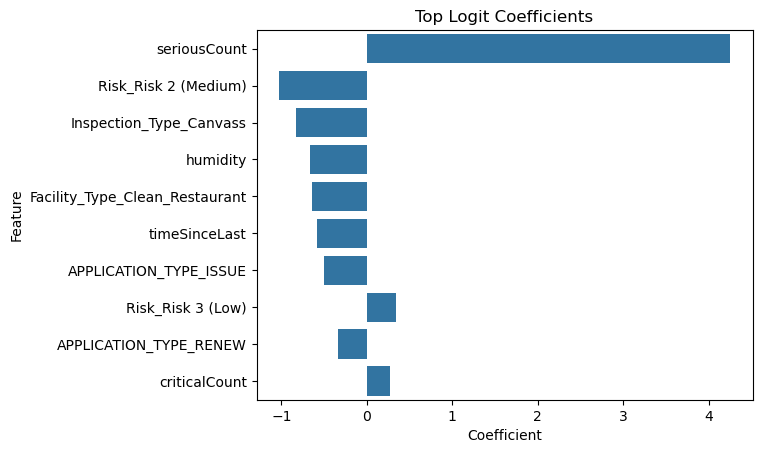

In [29]:
# outputs from logit model 
# extract the coefficents and create a dataframe for plotting 
logit_data = pd.concat([pd.DataFrame(X.columns),
                        pd.DataFrame(np.transpose(logit_model.coef_))],
                       axis = 1)

logit_data.columns = ['Feature', 'Coefficient']
logit_data['abs_coef'] = abs(logit_data['Coefficient'])

# plot 
sns.barplot(x="Coefficient", 
            y="Feature", 
            data=logit_data.nlargest(10, 'abs_coef')).set_title("Top Logit Coefficients")
plt.show()

Feature importance from XGboost: 

Feature importance from Random Forest:

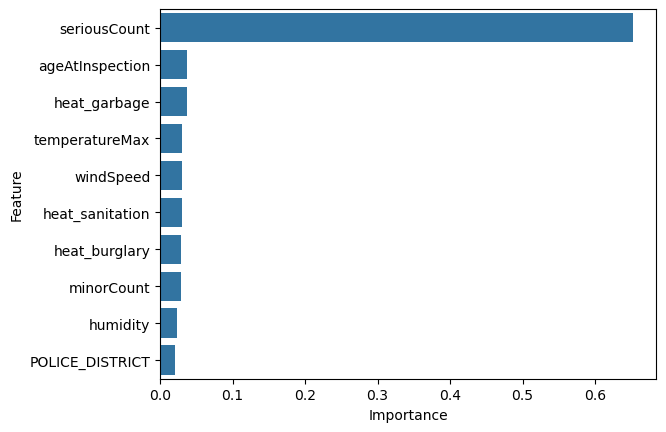

In [30]:
# fitting the forrest model 

# fit the random forest on data to get feature importance
# ----------
rf_classifier.fit(X, y.ravel())

# import library
import seaborn as sns

# create feature importance dataframe
feat_importances = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(rf_classifier.feature_importances_))], axis = 1)
feat_importances.columns = ["Feature", "Importance"]

# plot
sns.barplot(x = "Importance", 
            y = "Feature",  
            data = feat_importances.nlargest(10, 'Importance')) # identify the 10 most important features
plt.show()


serious Count is 6x more important than age at inspection, heat_garbage, temp Max, etc. at predicting if an establishment will pass or fail. This indicates that the most important feature in predicting a pass/fail is the number of times the establishment has failed in the past. note: I searched this variable meaning on Google.
I decided not to re-run this model only using a subsect of features since the most dominant is seriousCount, but the features following all are similarly rated in importance. The logit model corroborates that SeriousCount is a highly predictive feature.

The logistic model also shows a negative relationship between passing/failing and other covariates such as humidity, time since last inspection, inspection type canvass, and certain risk types in facilities. If I could get hands on more data, I'd be interested in seeing how the rater (or inspector)'s ratings vary to understand how within and between inspector variation affects an outcome for facilities. 

### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

Based on the F1 scor I'm interested in, I'm selecting Random Forest to predict outcomes and probabilities. 

In [51]:
y.shape

(15311, 1)

In [15]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# first, fitting RF 
rf_classifier.fit(X, y.ravel())

# next predicting outcomes with .predict() which gives predicted class labels 
y_pred = rf_classifier.predict(X)    

# 1. Predict probabilities
probs = rf_classifier.predict_proba(X)

# Find the index of "Fail" and pass
fail_idx = list(rf_classifier.classes_).index(1) #fail 
pass_idx = list(rf_classifier.classes_).index(0) #pass

# Extract probability of fail and pass
prob_fail = probs[:, fail_idx]
prob_pass = probs[:, pass_idx]


In [44]:
#
# 2. Order your audits by their probability of detecting a "Fail" score


# Sorting indices by highest fail probability
sorted_idx = prob_fail.argsort()[::-1]   # descending order

# Pick the top 1,000 highest-risk observations
top_1000_idx = np.argsort(prob_fail)[-1000:]

# 4 Look at actual pass/fail outcomes for those 1,000
top_1000_true_labels = y[top_1000_idx]


In [47]:
counts

1    1000
Name: count, dtype: int64

1    1000
Name: count, dtype: int64


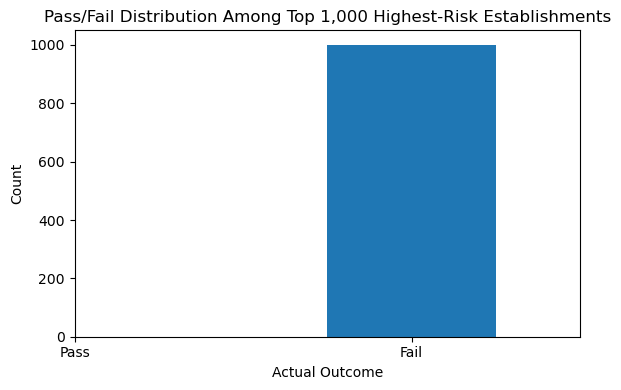

In [52]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# 
import pandas as pd
import matplotlib.pyplot as plt

# top_1000_idx should be a 1D array of integer indices (from argsort)
# top_1000_true_labels might be a numpy array or pandas Series depending on how y is stored.

# Ensure labels are a pandas Series indexed like X and change it with ravel
y = y.ravel()
y_series = pd.Series(y).reset_index(drop=True)

# Extract the true labels for the top 1000 indices
top_1000_labels = y_series.iloc[top_1000_idx]

counts = top_1000_labels.value_counts().sort_index()
print(counts)

counts.plot.bar(figsize=(6,4))

plt.xticks([-1,0], ['Pass', 'Fail'], rotation=0)
plt.title("Pass/Fail Distribution Among Top 1,000 Highest-Risk Establishments")
plt.ylabel("Count")
plt.xlabel("Actual Outcome")
plt.tight_layout()
plt.show()

# using [-1,0] as the column index for xticks since the data structure is 1 1000

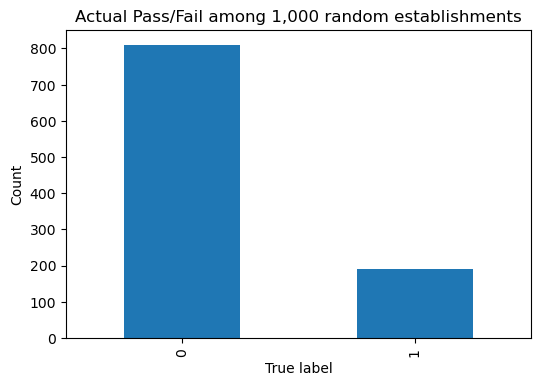

In [50]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random


y = y.ravel()
y_series = pd.Series(y).reset_index(drop=True)

# Extract the true labels for the top 1000 indices
top_1000_true_labels = y_series.sample(1000)

counts = top_1000_true_labels.value_counts()
counts.plot(kind='bar', figsize=(6,4))
plt.title("Actual Pass/Fail among 1,000 random establishments")
plt.xlabel("True label")
plt.ylabel("Count")
plt.show()



In [49]:
counts 

1    1000
Name: count, dtype: int64

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [29]:
# data processing
# -----------

# process features
X_test2014 = chicago_inspections_2014.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

# we dropped the columns in our feature dataset that we are interested in. 
# get dummies
X_test2014 = pd.get_dummies(X)

# process target 
y_test2014 = chicago_inspections_2014['Results']

y_test2014.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y_test2014 = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y_test2014 = np.where(y == 1, 0 ,1)



In [35]:
# predict and compare 

# test train split 
np.random.seed(10)
X_train2014, X_validate2014, y_train2014, y_validate2014 = train_test_split(
    X_test2014, 
    y_test2014, 
    train_size=.80, 
    test_size=.20, 
    stratify=y_test2014
)


# create a model
logit_reg = LogisticRegression()


# hyperparamter tuning set parameters
param_grid = {'penalty': ['l1', 'l2', 'elasticnet'],
             'C': np.arange(.1, 1, .1),
             'fit_intercept': [True, False],
             'solver': ['liblinear', 'saga']}


# execute the grid search and fit to test data
logit_grid = GridSearchCV(logit_reg, 
                          param_grid, 
                          cv=3)
logit_grid.fit(X_test2014, 
               y_test2014)

# choose best performing model
best_index = np.argmax(logit_grid.cv_results_["mean_test_score"])
best_logit_pred = logit_grid.best_estimator_.predict(X_validate2014)

# print results
print(logit_grid.cv_results_["params"][best_index])
print('Validation Accuracy', accuracy_score(best_logit_pred, y_validate2014))


{'C': np.float64(0.1), 'fit_intercept': True, 'penalty': 'elasticnet', 'solver': 'liblinear'}
Validation Accuracy 0.9262161279791055


In [36]:
# evaluate with scoring

from sklearn.model_selection import cross_validate

# list of models and labels
models = [
    (logit_reg, 'Logistic Regression'),
]

# metrics to compute
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# for loop in each model 
for clf, label in models:
    print(f"\nModel: {label}")
    
    results = cross_validate(
        clf,
        X_test2014,
        y.ravel(),
        scoring=scoring,
        cv=5,
        return_train_score=False
    )
    
    # print mean of each metric across CV folds
    print(f"Accuracy:  {results['test_accuracy'].mean():.3f}")
    print(f"Precision: {results['test_precision'].mean():.3f}")
    print(f"Recall:    {results['test_recall'].mean():.3f}")
    print(f"F1 Score:  {results['test_f1'].mean():.3f}")




Model: Logistic Regression
Accuracy:  0.918
Precision: 0.769
Recall:    0.855
F1 Score:  0.808


## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


While the logit model did well in accuracy, it performed weaker in  recall, and F1 score, and poor in precision. If we were to have just used accuracy as our scoring metric, we would have felt confidence in this logit model for prediction. However, we see that the low score in precision, which means that for all the facilities indicated as pass, 76% were actually correct (which is not something we'd have strong confidence in). For social science and policy spaces, where many important decisions are made based on predictions using machine learning algorithms, it is important to understand the implications of false positives and false negatives with accuracy. For the healthcare space,  a false negative can be an extremely important metric, but for a policy evaluating pass/fail of restaurants, a false positive can be very important. Each domain and issue has different metrics that are important to consider, and accuracy doesn't account for many of these implications.

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

This is a salient problem observed when actors can see how algorithms work and change behaviors to avoid detection or being flagged as a resetaurant that would fail. To account for some of this interplay, policymakers can still continue to randomize some facility searches in addition to using the algorithm to ensure that there is some reservation of auditing power. Additionally, outside of those who need access to it, the algorithm can have high-level information disclosed so that there is transparency of what mechanisms are going on, but there is not too much flexibility for actors to change their behavior as a result. There are lots of pros and cons for algorithmic decision making, but some of these cons can be mitigated by continued human involvement and infrastructure being reserved for monitoring.